## This file generates the figures of our case examples in Figure 2.

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle as pkl
import cv2
from collections import defaultdict
from config.datasets import *
from config.models import *
from config.figures import *

In [2]:
# Participant ID and the corresponding AU example
sel_examples = [{'participant': 'SN024', 'AU': 1},
                {'participant': 'SN012', 'AU': 4},
                {'participant': 'SN010', 'AU': 9},
                {'participant': 'SN013', 'AU': 17}]

In [3]:
# Infomation of the two main methods to investigate
infos = {"IR50 (NCG)": {"task": "DISFA_AU_intensity_estimation_threefold", "dataset": "DISFA", "n_folds": 3, "AUs": DISFA_AUS_IE, "label_type": "intensity", "model": "IR50", "sub_idx": -2},
         "CSN-IR50 (OFC)": {"task": "DISFA_AU_intensity_estimation_threefold", "dataset": "DISFA", "n_folds": 3, "AUs": DISFA_AUS_IE, "label_type": "intensity", "model": "CSN-IR50-stage4", "sub_idx": -2, "FPS": DISFA_FPS}}

In [4]:
model_pred_labels = {}
for model, info in infos.items():
    # Load the data
    all_image_paths = []
    all_pred_labels = np.empty([0, len(info["AUs"])])
    all_true_labels = np.empty([0, len(info["AUs"])])
    for fold in range(1, info["n_folds"]+1):
        path = os.path.join("results", info["task"], info["model"], "results", f"fold-{fold}", f"val_results_epoch{N_EPOCHS}.pkl")
        with open(path, "rb") as f:
            D = pkl.load(f)
            image_paths = [path_pair.split(' ')[-1] for path_pair in D['image_paths']]
            if info["label_type"] == "intensity":
                pred_labels = D['pred_labels_regression']
            elif info["label_type"] == "occurrence":
                pred_labels = D['pred_labels']
            true_labels = D['true_labels']
            all_image_paths.extend(image_paths)
            all_pred_labels = np.concatenate([all_pred_labels, pred_labels])
            all_true_labels = np.concatenate([all_true_labels, true_labels])

    all_image_paths = np.array(all_image_paths)

    # Use the left-view videos for DISFA
    if info["dataset"] == "DISFA":
        left_idx = np.vectorize(lambda x: 'Left' in x)(all_image_paths)
        all_image_paths = all_image_paths[left_idx]
        all_pred_labels = all_pred_labels[left_idx]
        all_true_labels = all_true_labels[left_idx]
    
    # Ensure that the data are ordered according to the frame indices
    if info["dataset"] == "DISFA":
        reorder_idx = np.lexsort((np.vectorize(lambda p: int(p.split('/')[-1].split('.')[0]))(all_image_paths), np.vectorize(lambda p: p.split('/')[info["sub_idx"]])(all_image_paths)))
        all_image_paths = all_image_paths[reorder_idx]
        all_pred_labels = all_pred_labels[reorder_idx]
        all_true_labels = all_true_labels[reorder_idx]
    
    # Find out the indices for each participant in the results
    subject_indices = defaultdict(list)
    for index, path in enumerate(all_image_paths):
        subject_indices[path.split('/')[info["sub_idx"]]].append(index)

    model_pred_labels[model] = all_pred_labels

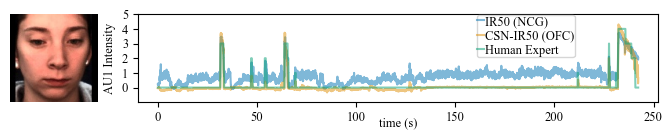

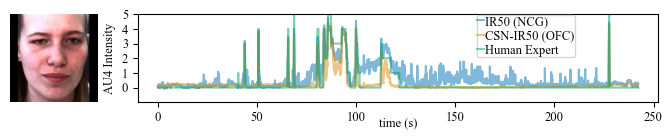

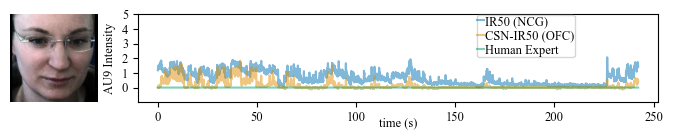

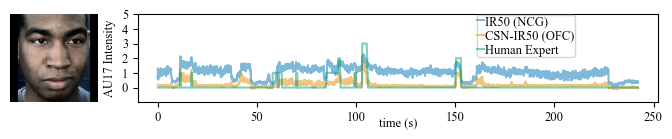

In [5]:
# Plot each case example
for example in sel_examples:
    sub_ID = example['participant']
    AU = example['AU']

    fig = plt.figure(figsize=(8, 1.1))
    ax1 = fig.add_axes([0.1, 0.1, 0.15, 0.8])
    ax2 = fig.add_axes([0.28, 0.1, 0.65, 0.8])

    img_path = os.path.join(f"{DISFA_IMG_ROOTDIR_LEFTCAM}_preprocessed", sub_ID, f"{DISFA_BASELINE_FRAMES[sub_ID]}.jpg")
    img = cv2.imread(img_path)
    ax1.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax1.axis('off')

    frame_indices = np.array(list(map(lambda p: int(p.split('/')[-1].split('.')[0]), all_image_paths[subject_indices[sub_ID]])))
    timestamps = frame_indices / info["FPS"]
    for i, (model, pred_labels) in enumerate(model_pred_labels.items()):
        ax2.plot(timestamps, pred_labels[subject_indices[sub_ID],info["AUs"].index(AU)], alpha=ALPHA, label = model, color = COLORS[i])
    ax2.plot(timestamps, all_true_labels[subject_indices[sub_ID],info["AUs"].index(AU)], alpha=ALPHA, label = f'Human Expert', color = COLORS[2])
    ax2.set_xlim(timestamps.min()-10, timestamps.max() + 10)
    ax2.set_ylim([-1, 5])
    ax2.set_xticks([0, 50, 100, 150, 200, 250])
    ax2.set_yticks([0, 1, 2, 3, 4, 5])
    ax2.set_xlabel('time (s)', labelpad=-5)
    ax2.set_ylabel(f'AU{AU} Intensity')
    ax2.legend(loc='upper left', bbox_to_anchor=(0.65, 1), handlelength=0.5, handletextpad=0.1, borderpad=0.05, labelspacing=0.2, borderaxespad=0.05)
    
    plt.savefig(os.path.join('figures', f"AU{AU}.pdf"), format='pdf', bbox_inches='tight', pad_inches=0.01)
    plt.show()